In [1]:
"""Training-only exploratory data analysis for Stroke Rehab.

Run from the repository root after `stroke-rehab download` and `stroke-rehab diagnose`.
Set STROKE_REHAB_DATA to an alternate extracted directory. No test EEG is loaded.
"""
from pathlib import Path
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from stroke_rehab.data import read_recording, session_paths

DATA = Path(os.environ.get("STROKE_REHAB_DATA", "data/stroke-rehab"))
OUT = Path("results")
OUT.mkdir(exist_ok=True)
print("EDA uses only organizer training runs.")


EDA uses only organizer training runs.


In [2]:
# Count trials as trigger blocks rather than nonzero trigger samples.
summary = []
for patient, session, training, _ in session_paths(DATA):
    rec = read_recording(training)
    assert (np.diff(rec.onsets) >= 8 * rec.fs).all()
    onset_gap = np.diff(rec.onsets) / rec.fs
    # Gross-excursion heuristic, within-run and per-channel: not clinical artifact labels.
    segments = np.stack([rec.signal[t + round(2.5 * rec.fs):
                                     t + round(6.5 * rec.fs)] for t in rec.onsets])
    peak_to_peak = np.ptp(segments, axis=1)
    med = np.median(peak_to_peak, axis=0)
    gross = np.any(peak_to_peak > 5 * np.maximum(med, 1e-12), axis=1)
    summary.append(dict(patient=patient, session=session,
                        samples=len(rec.signal), minutes=round(len(rec.signal)/rec.fs/60, 2),
                        trials=len(rec.labels), left=int((rec.labels == 1).sum()),
                        right=int((rec.labels == -1).sum()),
                        gap_median_s=round(float(np.median(onset_gap)), 3),
                        gap_max_s=round(float(np.max(onset_gap)), 3),
                        gross_excursion_trials=int(gross.sum())))
qc = pd.DataFrame(summary)
qc.to_csv(OUT / "train_signal_qc.csv", index=False)
display(qc)


,patient,session,samples,minutes,trials,left,right,gap_median_s,gap_max_s,gross_excursion_trials
0,P1,pre,271816,17.70,80,40,40,9.605,41.371,2
1,P1,post,197343,12.85,80,40,40,9.031,48.938,0
2,P2,pre,223112,14.53,80,40,40,9.594,60.891,0
3,P2,post,216720,14.11,80,40,40,9.594,51.668,2
4,P3,pre,205536,13.38,80,40,40,9.574,37.594,0
5,P3,post,206504,13.44,80,40,40,9.594,42.781,0


Training-only correct trials by diagnostic and split:


feature         post_cue_offline_csp        pre_cue_causal_power       
split                 blocked_purged random       blocked_purged random
patient session                                                        
P1      post                      79     79                   31     33
        pre                       75     77                   39     46
P2      post                      74     74                   33     37
        pre                       71     71                   34     35
P3      post                      68     68                   36     36
        pre                       72     72                   31     30

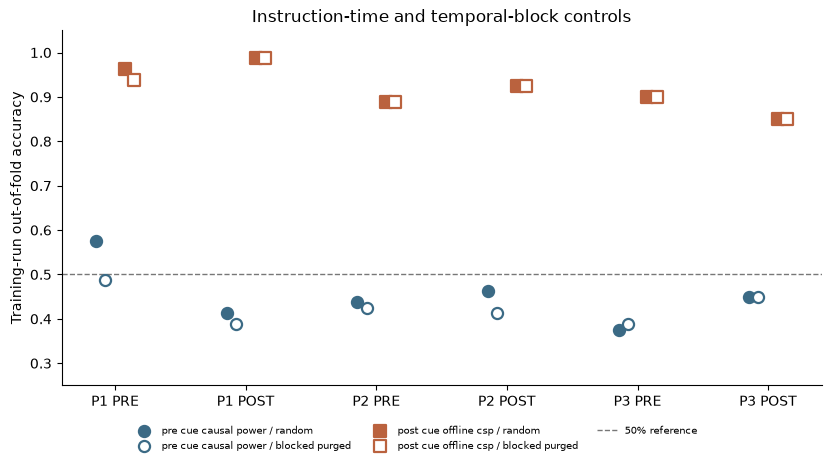

In [3]:
# Diagnostic scores are *only* out-of-fold training-run scores.
diag = pd.read_csv(OUT / "train_diagnostics.csv")
assert len(diag) == 24 and set(diag["trials"]) == {80}
print("Training-only correct trials by diagnostic and split:")
display(diag.pivot_table(index=["patient", "session"],
                         columns=["feature", "split"], values="correct", aggfunc="first"))

fig, ax = plt.subplots(figsize=(8.2, 4.5), layout="constrained")
keys = [(p, s) for p in ("P1", "P2", "P3") for s in ("pre", "post")]
colors = {"pre_cue_causal_power": "#3B6A85", "post_cue_offline_csp": "#BA623E"}
for feat, marker, dx in [("pre_cue_causal_power", "o", -0.11),
                         ("post_cue_offline_csp", "s", 0.11)]:
    subset = diag[diag.feature == feat]
    for split, face, shift in [("random", colors[feat], -0.035),
                               ("blocked_purged", "white", 0.035)]:
        vals = [subset[(subset.patient == p) & (subset.session == s) &
                       (subset.split == split)].accuracy.iloc[0] for p, s in keys]
        ax.scatter(np.arange(6) + dx + shift, vals, s=64, marker=marker,
                   facecolor=face, edgecolor=colors[feat], linewidth=1.6,
                   label=f"{feat.replace('_', ' ')} / {split.replace('_', ' ')}", zorder=3)
ax.axhline(0.5, color="#777777", linestyle="--", lw=1, label="50% reference")
ax.set(xticks=np.arange(6), xticklabels=[f"{p} {s.upper()}" for p, s in keys],
       ylabel="Training-run out-of-fold accuracy", ylim=(0.25, 1.05),
       title="Instruction-time and temporal-block controls")
fig.legend(frameon=False, fontsize=7, ncol=3, loc="outside lower center")
ax.spines[['top', 'right']].set_visible(False)
fig.savefig(OUT / "train_diagnostics.png", dpi=320, bbox_inches="tight")
plt.show()
